In [1]:
%cd ..

/home/dev/workspace


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-06-15_23-13-25/saved/checkpoint-epoch100.npy", 
                                                            "+experiment=airish", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

E0615 23:28:02.938346  142649 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
Best ckpt not found! Using current weights for testing...


In [5]:
metrics

{'loss': np.float32(422004.88),
 'log_w': np.float32(-422004.84),
 'ess': np.float32(0.25175905)}

In [6]:
for data, target in objects['datamodule'].test_dataloader():
    trace = objects['learner'](data)
    recons = trace['x'].mean(axis=0).reshape(data.shape[0], 1, 50, 50)
    z_where = jnp.concatenate((trace["glimpse_scale"], trace["glimpse_translate"]), axis=-1).mean(axis=0)
    break

/home/dev/workspace/src/inference/tracer.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


In [7]:
def z_where_inv(z_where):
    # Take a batch of z_where vectors, and compute their "inverse".
    # That is, for each row compute:
    # [s,x,y] -> [1/s,-x/s,-y/s]
    # These are the parameters required to perform the inverse of the
    # spatial transform performed in the generative model.
    s = z_where[0]
    return np.array([1 / s, -z_where[1] / s, -z_where[2] / s]).T

def bounding_box(z_where, x_side):
    """This doesn't take into account interpolation, but it's close
    enough to be usable."""
    w = x_side / z_where[0]
    h = x_side / z_where[0]
    xtrans = z_where[1] / z_where[0] * x_side / 2.0
    ytrans = z_where[2] / z_where[0] * x_side / 2.0
    x = (x_side - w) / 2 + xtrans  # origin is top left
    y = (x_side - h) / 2 + ytrans
    return (x, y), w, h

def colors(k):
    return np.array([(1, 0, 0), (0, 1, 0), (0, 0, 1)])[k % 3]

def draw_z_where(z_where, x_side, k=0):
    import matplotlib.patches as patches
    ax = plt.gca()
    rect = patches.Rectangle(*bounding_box(z_where, x_side), edgecolor=colors(k), facecolor=[0, 0, 0, 0], linewidth=2)
    ax.add_patch(rect)

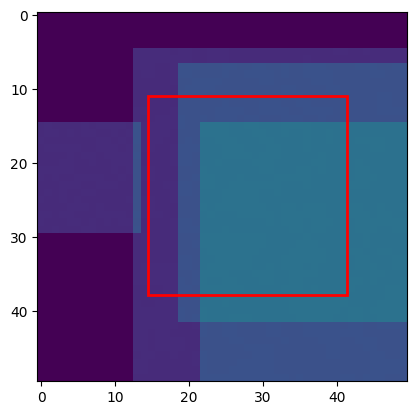

In [8]:
plt.imshow(recons[0].squeeze(), vmin=0., vmax=1.)
draw_z_where(z_where[0], recons[0].shape[-1])

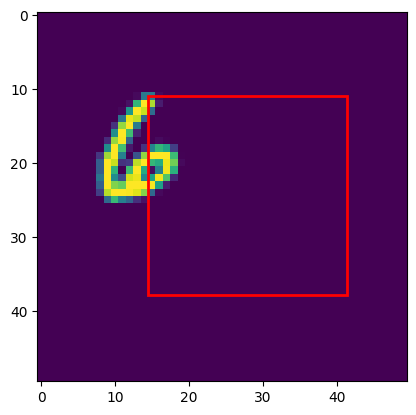

In [9]:
plt.imshow(data[0].squeeze(), vmin=0., vmax=1.)
draw_z_where(z_where[0], recons[0].shape[-1])

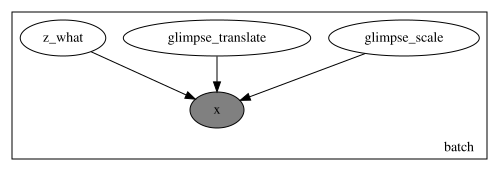

In [10]:
objects['learner'].render_model()